# Naive Bayes

Implementation of Naive Bayes from scratch using only Python and NumPy.

This notebook implements two versions of Naive Bayes:

- Multinomial Naive Bayes, commonly used for text classification and word-count features.
- Gaussian Naive Bayes, commonly used for continuous numerical features.

For Multinomial Naive Bayes, the model estimates the probability of each word given each class using Laplace smoothing.

For Gaussian Naive Bayes, the model assumes that each feature follows a Gaussian distribution within each class. During training, the model estimates the mean and variance of each feature for each class.

The prediction is made by computing the log posterior score for each class and selecting the class with the highest score.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Class

In [26]:
class Naive_Bayes:
    def __init__(self, type="multinomial", alpha=1, epsilon=1e-9):
        """
        Initializes the Naive Bayes classifier.
        :param type: The type of Naive Bayes to use. Options are "multinomial" and "gaussian".
        :type type: str
        :param alpha: The Laplace smoothing parameter used for multinomial Naive Bayes.
        :type alpha: int or float
        :param epsilon: Small value added to variances to avoid division by zero.
        :type epsilon: float
        """
        self.type = type
        self.alpha = alpha
        self.epsilon = epsilon

        self.classes = None
        self.priors = {}

        self.word_probs = {}

        self.mean = {}
        self.var = {}

    def fit(self, X, y):
        """
        Fits the Naive Bayes classifier using the training data.
        :param X: The training feature matrix.
        :type X: np.ndarray
        :param y: The training labels.
        :type y: np.ndarray
        :return: The fitted classifier instance.
        :rtype: Naive_Bayes
        """
        X = np.array(X)
        y = np.array(y)

        self.classes = np.unique(y)

        if self.type == "multinomial":
            n_samples, n_words = X.shape

            for c in self.classes:
                X_c = X[y == c]
                self.priors[c] = X_c.shape[0] / n_samples
                word_counts = X_c.sum(axis=0)
                total_words = word_counts.sum()
                modified_count = word_counts + self.alpha
                modified_total = total_words + self.alpha
                self.word_probs[c] = modified_count / modified_total

        elif self.type == "gaussian":
            n_samples, n_features = X.shape

            for c in self.classes:
                X_c = X[y == c]
                self.priors[c] = X_c.shape[0] / n_samples
                self.mean[c] = np.mean(X_c, axis=0)
                self.var[c] = np.var(X_c, axis=0) + self.epsilon

        else:
            raise ValueError(f"Unknown type: {self.type}")

        return self

    def _predict_one_multinomial(self, x):
        """
        Predicts the class of a single sample using multinomial Naive Bayes.
        :param x: A single input sample represented as word counts.
        :type x: np.ndarray
        :return: The predicted class.
        """
        scores = {}
        for c in self.classes:
            log_prior = np.log(self.priors[c])
            log_likelihood = np.sum(x * np.log(self.word_probs[c]))
            scores[c] = log_prior + log_likelihood

        return max(scores, key=scores.get)

    def _predict_one_gaussian(self, x):
        """
        Predicts the class of a single sample using Gaussian Naive Bayes.
        :param x: A single input sample with continuous features.
        :type x: np.ndarray
        :return: The predicted class.
        """
        scores = {}

        for c in self.classes:
            mean = self.mean[c]
            var = self.var[c]

            log_prior = np.log(self.priors[c])

            log_likelihood = -0.5 * np.log(2 * np.pi * var)
            log_likelihood -= ((x - mean) ** 2) / (2 * var)

            scores[c] = log_prior + np.sum(log_likelihood)

        return max(scores, key=scores.get)

    def _predict_one(self, x):
        """
        Predicts the class of a single input sample.
        :param x: A single input sample.
        :type x: np.ndarray
        :return: The predicted class.
        """
        if self.type == "multinomial":
            return self._predict_one_multinomial(x)

        elif self.type == "gaussian":
            return self._predict_one_gaussian(x)

        else:
            raise ValueError(f"Unknown type: {self.type}")

    def predict(self, X):
        """
        Predicts class labels for one or more input samples.
        :param X: The input sample or feature matrix.
        :type X: np.ndarray
        :return: The predicted class label or an array of predicted labels.
        :rtype: int, float, str, or np.ndarray
        """
        X = np.array(X)

        if X.ndim == 1:
            return self._predict_one(X)

        predictions = []

        for x in X:
            predictions.append(self._predict_one(x))

        return np.array(predictions)

# Helpers

In [27]:
def build_vocabulary(texts):
    vocabulary = {}

    for text in texts:
        words = text.lower().split()

        for word in words:
            if word not in vocabulary:
                vocabulary[word] = len(vocabulary)

    return vocabulary


def vectorize_texts(texts, vocabulary):
    X = np.zeros((len(texts), len(vocabulary)))

    for i, text in enumerate(texts):
        words = text.lower().split()

        for word in words:
            if word in vocabulary:
                X[i, vocabulary[word]] += 1

    return X

# Importing datasets

In [28]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load the Iris dataset
iris = load_iris()

X = iris.data

y = iris.target

print("X:", X.shape)

print("y:", y.shape)

print("Classes:", iris.target_names)

print("Features:", iris.feature_names)

X: (150, 4)
y: (150,)
Classes: ['setosa' 'versicolor' 'virginica']
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [29]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print("X_train:", X_train.shape)

print("y_train:", y_train.shape)

print("X_test:", X_test.shape)

print("y_test:", y_test.shape)

X_train: (120, 4)
y_train: (120,)
X_test: (30, 4)
y_test: (30,)


In [30]:
# Train Gaussian Naive Bayes

nb = Naive_Bayes(type="gaussian")

nb.fit(X_train, y_train)

# Predict

y_pred = nb.predict(X_test)

# Evaluate

accuracy = np.mean(y_pred == y_test)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9667


In [31]:
# Test one sample

index = 0

x_sample = X_test[index]

true_label = y_test[index]

predicted_label = nb.predict(x_sample)

print("Input sample:", x_sample)

print("True label:", iris.target_names[true_label])

print("Predicted label:", iris.target_names[predicted_label])

Input sample: [4.4 3.  1.3 0.2]
True label: setosa
Predicted label: setosa


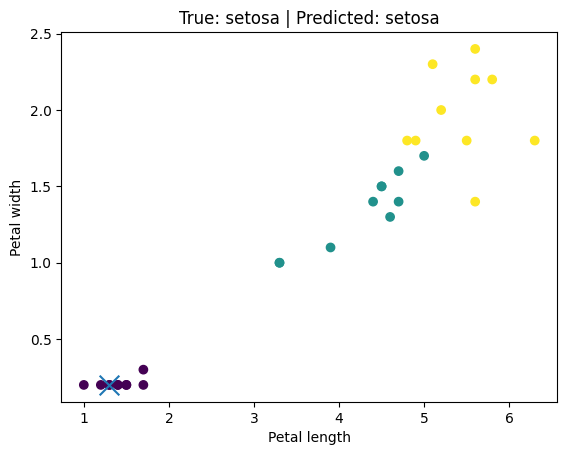

In [32]:
# Visualize prediction using two Iris features
index = 0

plt.scatter(X_test[:, 2], X_test[:, 3], c=y_test)
plt.scatter(X_test[index, 2], X_test[index, 3], s=200, marker="x")

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title(
    f"True: {iris.target_names[y_test[index]]} | "
    f"Predicted: {iris.target_names[nb.predict(X_test[index])]}"
)

plt.show()

In [33]:
texts_train = [
    "free money now",
    "win free prize",
    "free offer money",
    "claim free money",
    "meeting today project",
    "project deadline today",
    "schedule meeting now",
    "team project meeting"
]

y_train = np.array([
    "spam",
    "spam",
    "spam",
    "spam",
    "ham",
    "ham",
    "ham",
    "ham"
])

texts_test = [
    "free money",
    "meeting project",
    "free prize now",
    "team deadline"
]

y_test = np.array([
    "spam",
    "ham",
    "spam",
    "ham"
])

In [34]:
# Build vocabulary using only training data
vocabulary = build_vocabulary(texts_train)

# Convert text to bag-of-words vectors
X_train = vectorize_texts(texts_train, vocabulary)
X_test = vectorize_texts(texts_test, vocabulary)

print("Vocabulary:", vocabulary)
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Vocabulary: {'free': 0, 'money': 1, 'now': 2, 'win': 3, 'prize': 4, 'offer': 5, 'claim': 6, 'meeting': 7, 'today': 8, 'project': 9, 'deadline': 10, 'schedule': 11, 'team': 12}
X_train: (8, 13)
y_train: (8,)
X_test: (4, 13)
y_test: (4,)


In [35]:
# Train Multinomial Naive Bayes
nb = Naive_Bayes(type="multinomial", alpha=1)

nb.fit(X_train, y_train)

# Predict
y_pred = nb.predict(X_test)

# Evaluate
accuracy = np.mean(y_pred == y_test)

print("Predictions:", y_pred)
print("True labels:", y_test)
print(f"Accuracy: {accuracy:.4f}")

Predictions: ['spam' 'ham' 'spam' 'ham']
True labels: ['spam' 'ham' 'spam' 'ham']
Accuracy: 1.0000


In [36]:
# Test one custom sentence
sentence = ["free project money"]

X_sentence = vectorize_texts(sentence, vocabulary)

prediction = nb.predict(X_sentence)

print("Sentence:", sentence[0])
print("Prediction:", prediction[0])

Sentence: free project money
Prediction: spam
